COE 311K Final Project Part 3 Written Part

Section 1 - 
I used the same bacteria population model from part 2 for part 3. The equation is dN/dt = -lambda(N - Nc(t)), where N is the bacteria population, lambda is 1000, and there is a starting population of 100000. The carrying capacity, whihc is Nc(t), changes slowly using a sine function to represent resources changing over time. The Euler's Forward method still needs a very small step size to be accurate and run quick, while the Backwards Euler method can use much bigger steps and still be efficient. For this part, I added the damped Newton-Raphson and adaptive step size control in this part.

Section 2 - 
The Normal Newton-Raphson uses the full update of x = x - g(x)/g'(x) each time. Sometimes that can overshoot if the guess is bad or the step size is large, but can work well if the initial guess is closer to the solution, but this requires someone to give a good guess. Damping fixes this by multiplying the update by a random alpha value between 0 and 1, as shown with this equation: x = x + alpha*(-g(x)/g'(x)). 

For this model, the equation is linear, so Newton-Raphson already converges in one step regardless of the step size, which is the same as the damped version. Because of that, damping was usually not needed becuase the damped and undamped versions were pretty much the same. However, for nonlinear problems, damping would matter more and would definitely increase the accuracy and the efficiency of the method..

Section 3 - 
Adaptive step size works by comparing one full step of size h with two half steps and then the difference between them estimates the size of the local error through this fomula: err = |y_half - y_full|. If the error is below the tolerance, then the step is accepted and if not, then the step is rejected and h gets smaller. The new h is based on the formula: h_new = safety * h * sqrt(tol/err). The safety in the equation helps avoid changing h too aggressively and keep the solutions from blowing up or getting rejected.

Section 4 - 
Adaptive stepping can save work because it uses larger steps when the solution is smooth but can also use smaller steps when needed to save time. Meanwhile, fixed stepping uses the same h everywhere, which can waste time and increase the runtime of the code. For this problem, which is smooth, the adaptive solver used 65 steps compared to 60 for the fixed step size case with h = 0.5, but for a more complex problem, there would theoretically be a much bigger difference, and adaptive would be better.

Section 5 - 
Because there was a large starting step size, the solver rejected some early steps and then adjusted itself because of adaptive stepping. However, because the tolerance was smaller, being 1e-7 instead of 1e-4, it used more but smaller steps, so it went from 65 to 348. Both versions still finished successfully, which proved that the method was stable and could handle a more difficult setting.

Section 6 - 
Damping is much more useful for nonlinear equations where Newton-Raphson may fail, so it wasn't very noticeable because this equation is linear. Adaptive step size is useful because it chooses your h-value automatically and doesn't need the user to have a good guess. It can improve efficiency and accuracy without needing as much trial and error from the user. 

Overall, combining all of them, including implicit Euler, damping, and adaptive stepping gives a stronger and more effieicient and accurate solver for stiff ODE problems. However, there are cases where undamped and unadaptive versions can be faster.

I used Claude to research more about these methods and find out why my code was taking too long and not running. 

[1] Anthropic, "Claude (claude-sonnet-4-6)," Large language model, 2025. [Online]. Available: https://www.anthropic.com

h 0.1 iterations 1 damping False
h 1.0 iterations 1 damping False
h 5.0 iterations 1 damping False
h 10.0 iterations 2 damping False


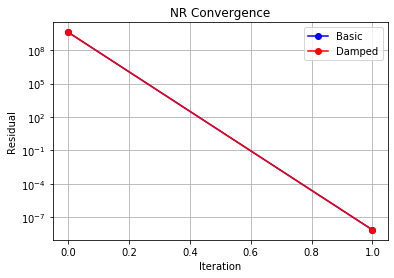

Accepted 65
Rejected 6
Total iterations 213


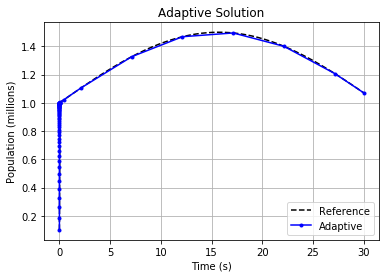

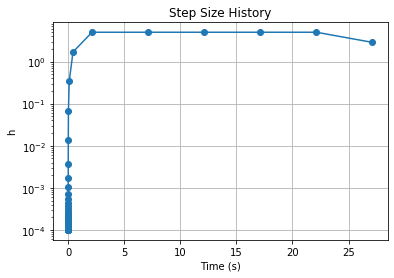

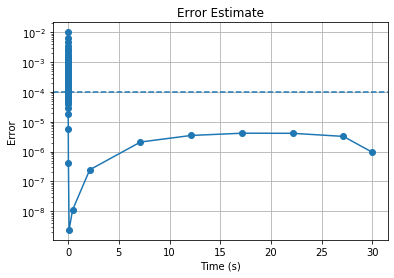

Fixed steps 60
Adaptive steps 65


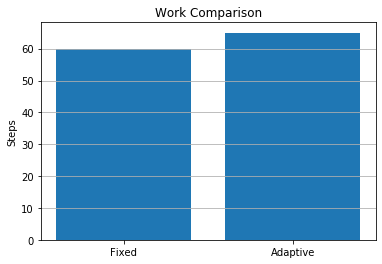

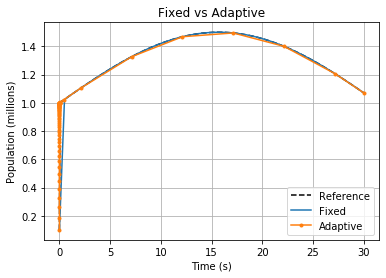

Large h accepted 65
Tight tol accepted 348


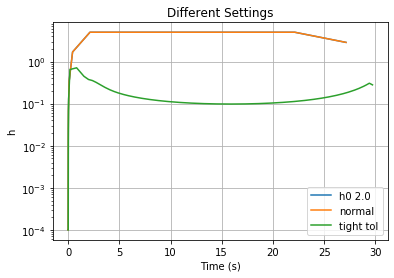

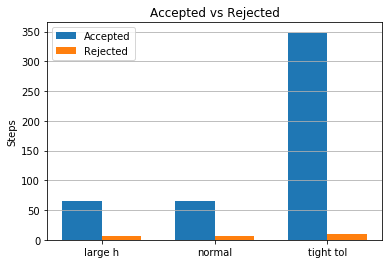

In [11]:
# COE 311K Final Project Part 3
# Option E: Population with Rapid Birth/Death Cycles
# System: Bacterial Cultures
# Name: Soham Kinkhabwala
# EID: sbk788

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# basic values (same as Part 2)
lam = 1000.0
N0 = 1e5
t0 = 0.0
tf = 30.0

def Ncarry(t):
    return 1e6 * (1 + 0.5*np.sin(0.1*t))

def f(t, n):
    return -lam*n + lam*Ncarry(t)

# reference solution
ref = solve_ivp(f, [t0, tf], [N0], method="Radau",
                dense_output=True, rtol=1e-10, atol=1e-12)

t_ref = np.linspace(t0, tf, 500)
n_ref = ref.sol(t_ref)[0]

# backward euler function (same as Part 2)
def g(x, old, t_next, h):
    return x - old - h*f(t_next, x)

def g_prime(h):
    return 1 + h*lam

def newton(old, t_next, h, tol=1e-6, max_it=20):
    x = old
    c = 0

    for j in range(max_it):
        val = g(x, old, t_next, h)

        if abs(val) < tol:
            break

        x = x - val/g_prime(h)
        c = c + 1

    return x, c

def backward(h, t0, tf, n0):
    t = np.arange(t0, tf+h, h)
    t = t[t <= tf + 1e-10]

    n = np.zeros(len(t))
    n_iters = np.zeros(len(t), dtype=int)
    n[0] = n0

    for i in range(1, len(t)):
        n[i], n_iters[i] = newton(n[i-1], t[i], h)

    return t, n, n_iters


# Section 7: Damped Newton-Raphson
def damped_newton(old, t_next, h, tol=1e-6, max_it=20, alpha_min=1e-4):
    x = old
    used = False
    n_backs = 0
    count = 0

    for j in range(max_it):
        val = g(x, old, t_next, h)

        if abs(val) < tol:
            break

        step = -val/g_prime(h)
        a = 1.0
        cur = abs(val)

        for k in range(10):
            test = x + a*step
            new_val = abs(g(test, old, t_next, h))

            if new_val < cur:
                break

            a = a/2
            n_backs = n_backs + 1

            if a < alpha_min:
                break

        if a < 1:
            used = True

        x = x + a*step
        count = count + 1

    else:
        print(f"  Warning: Damped NR did not converge at t = {t_next:.3f}")

    return x, count, used, n_backs

for h in [0.1, 1.0, 5.0, 10.0]:
    ans = damped_newton(N0, t0+h, h)
    print("h", h, "iterations", ans[1], "damping", ans[2])

# graph 6 - NR convergence comparison (basic vs damped)
basic_hist = []
x = N0*50

for i in range(10):
    val = g(x, N0, t0+1, 1)
    basic_hist.append(abs(val))
    if abs(val) < 1e-6:
        break
    x = x - val/g_prime(1)

damp_hist = []
x = N0*50

for i in range(10):
    val = g(x, N0, t0+1, 1)
    damp_hist.append(abs(val))
    if abs(val) < 1e-6:
        break

    step = -val/g_prime(1)
    a = 1.0

    for j in range(10):
        test = x + a*step
        if abs(g(test, N0, t0+1, 1)) < abs(val):
            break
        a = a/2

    x = x + a*step

plt.figure()
plt.semilogy(range(len(basic_hist)), basic_hist, 'b-o', label="Basic")
plt.semilogy(range(len(damp_hist)), damp_hist, 'r-o', label="Damped")
plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.title("NR Convergence")
plt.legend()
plt.grid(True)
plt.show()


# Section 8: Adaptive Step Size
def one_step(old, t_next, h):
    out, n_it, u, b = damped_newton(old, t_next, h)
    return out, n_it

def step_error(old, tn, h):
    full, i1 = one_step(old, tn+h, h)

    half1, i2 = one_step(old, tn+h/2, h/2)
    half2, i3 = one_step(half1, tn+h, h/2)

    scale = max(abs(full), abs(half2), 1.0)
    err = abs(half2-full)/scale

    return full, half2, err, i1+i2+i3

def adaptive(t0, tf, n0, h0, tol, h_min=1e-4, h_max=5.0, safety=0.9):
    t_list = [t0]
    n_list = [n0]
    h_list = []
    e_list = []

    h = h0
    n_acc = 0
    n_rej = 0
    work = 0

    while t_list[-1] < tf:
        tn = t_list[-1]
        nn = n_list[-1]

        if tn + h > tf:
            h = tf - tn

        full, half, err, cost = step_error(nn, tn, h)
        work = work + cost

        # compute new step size
        if err < 1e-14:
            h_new = min(h * 2.0, h_max)
        else:
            h_new = safety * h * np.sqrt(tol / err)
            h_new = max(h_min, min(h_max, h_new))

        h_new = max(0.2 * h, min(5.0 * h, h_new))
        h_new = max(h_min, min(h_max, h_new))

        if err < tol or h <= h_min:
            # accept step
            t_list.append(tn + h)
            n_list.append(half)
            h_list.append(h)
            e_list.append(err + 1e-16)
            n_acc += 1
            h = h_new
        else:
            n_rej += 1
            h = h_new

    info = {"accepted": n_acc, "rejected": n_rej, "iterations": work}
    return np.array(t_list), np.array(n_list), h_list, e_list, info


tol = 1e-4
t_adapt, n_adapt, h_hist, e_hist, info = adaptive(t0, tf, N0, 0.5, tol)

print("Accepted", info["accepted"])
print("Rejected", info["rejected"])
print("Total iterations", info["iterations"])

# adaptive solution vs reference
plt.figure()
plt.plot(t_ref, n_ref/1e6, 'k--', label="Reference")
plt.plot(t_adapt, n_adapt/1e6, 'b-o', ms=3, label="Adaptive")
plt.xlabel("Time (s)")
plt.ylabel("Population (millions)")
plt.title("Adaptive Solution")
plt.legend()
plt.grid(True)
plt.show()

# step size history
plt.figure()
plt.semilogy(t_adapt[:-1], h_hist, 'o-')
plt.xlabel("Time (s)")
plt.ylabel("h")
plt.title("Step Size History")
plt.grid(True)
plt.show()

# error estimate vs time
plt.figure()
plt.semilogy(t_adapt[1:], e_hist, 'o-')
plt.axhline(tol, ls='--')
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.title("Error Estimate")
plt.grid(True)
plt.show()


# performance comparison
t_fix, n_fix, it_fix = backward(0.5, t0, tf, N0)

print("Fixed steps", len(t_fix)-1)
print("Adaptive steps", info["accepted"])

# work comparison bar chart
plt.figure()
names = ["Fixed", "Adaptive"]
vals = [len(t_fix)-1, info["accepted"]]
plt.bar(names, vals)
plt.ylabel("Steps")
plt.title("Work Comparison")
plt.grid(True, axis='y')
plt.show()

# fixed vs adaptive solution comparison
plt.figure()
plt.plot(t_ref, n_ref/1e6, 'k--', label="Reference")
plt.plot(t_fix, n_fix/1e6, label="Fixed")
plt.plot(t_adapt, n_adapt/1e6, 'o-', ms=3, label="Adaptive")
plt.xlabel("Time (s)")
plt.ylabel("Population (millions)")
plt.title("Fixed vs Adaptive")
plt.legend()
plt.grid(True)
plt.show()


t1, n1, h1, e1, s1 = adaptive(t0, tf, N0, 2.0, 1e-4)
t2, n2, h2, e2, s2 = adaptive(t0, tf, N0, 0.5, 1e-7)

print("Large h accepted", s1["accepted"])
print("Tight tol accepted", s2["accepted"])

# step size history for different settings
plt.figure()
plt.semilogy(t1[:-1], h1, label="h0 2.0")
plt.semilogy(t_adapt[:-1], h_hist, label="normal")
plt.semilogy(t2[:-1], h2, label="tight tol")
plt.xlabel("Time (s)")
plt.ylabel("h")
plt.title("Different Settings")
plt.legend()
plt.grid(True)
plt.show()

# accepted vs rejected steps for different settings
plt.figure()
labs = ["large h", "normal", "tight tol"]
accs = [s1["accepted"], info["accepted"], s2["accepted"]]
rejs = [s1["rejected"], info["rejected"], s2["rejected"]]

x = np.arange(3)
w = 0.35

plt.bar(x-w/2, accs, w, label="Accepted")
plt.bar(x+w/2, rejs, w, label="Rejected")
plt.xticks(x, labs)
plt.ylabel("Steps")
plt.title("Accepted vs Rejected")
plt.legend()
plt.grid(True, axis='y')
plt.show()